In [1]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI
from pydantic import BaseModel,Field

load_dotenv()

llm=ChatOpenAI(model="deepseek-chat",
               base_url=os.getenv("DEEPSEEK_BASE_URL"),
               api_key=os.getenv("DEEPSEEK_API_KEY"),
               temperature=0)

In [10]:
from typing import Annotated, TypedDict
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage
from langgraph.graph import START, StateGraph, add_messages,END


class AgentState(TypedDict):
    messages:Annotated[list,add_messages]
    
def call_model(state):
    result=llm.invoke(state['messages'])
    return {'messages':[result]}

def translate_to(state):
    messages=state['messages'][-1]
    messages=([SystemMessage(
        content=
        "Please translate the text in any language into English as output")]+
              [HumanMessage(content=messages.content)])
    result=llm.invoke(messages)
    return {'messages':[result]}

builder=StateGraph(AgentState)
builder.add_node('call_model',call_model)
builder.add_node('translate_to',translate_to)

builder.add_edge(START,'call_model')
builder.add_edge('call_model','translate_to')
builder.add_edge('translate_to',END)

graph=builder.compile()

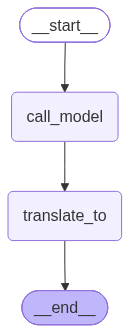

In [7]:
from IPython.display import display, Image


display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
# graph.invoke({'messages':["你好，介绍一下你自己"]})

async for event in graph.astream_events({'messages':["你好，介绍一下你自己"]},stream_mode="values"):
    if event['event']=='on_chat_model_stream':
        print(event['data']['chunk'].content,end='|',flush=True)

|你好|呀|！|很高兴|认识|你|！|😊|

|我是|**|Deep|Se|ek|**|，|由|深度|求|索|公司|创造的|AI|助手|。|让我|给你|介绍一下|我的|“|特长|”|：

|✨| **|我的|能力|**|：
|-| **|知识|广|博|**|：|我的|知识|截止|到|202|5|年|5|月|，|涵盖|各个|领域|
|-| **|超|强|上下文|**|：|支持|1|M|上下文|，|可以|一次性|处理|《|三|体|》|三部|曲|那么|大的|内容|！
|-| **|多|格式|支持|**|：|可以|处理|图片|、|PDF|、|Word|、|Excel|、|PPT|等多种|文件|格式|（|虽然|我是|纯|文本|模型|，|但|能|读取|这些|文件|中的|文字|信息|）
|-| **|联网|搜索|**|：|需要|时可以|帮你|搜索|最新|信息|（|需要|你|手动|开启|哦|）
|-| **|多|语言|交流|**|：|支持|多种|语言|，|包括|中文|、|英文|等|

|🎯| **|我的|特点|**|：
|-| **|完全|免费|**|：|没错|，|不|收费|！|你可以|尽情|使用|
|-| **|热情|细腻|**|：|我会|用心|理解|你的|需求|，|用|温暖|的方式|回应|
|-| **|实用|导向|**|：|无论是|学习|、|工作|还是|生活|问题|，|我都|乐意|帮忙|

|📱| **|使用|方式|**|：
|-| |网页|版|、|App|都可以|使用|
|-| App|支持|语音|输入|，|更方便|
|-| |可以在|官方|应用|商店|下载|

|有什么|我可以|帮|你的|吗|？|无论是|解答|疑惑|、|写作|协助|、|代码|编程|，|还是|单纯|聊|聊天|，|我|都很|乐意|陪伴|你|！|💪||||Hello| there|!| Nice| to| meet| you|!| 😊|

|I|'m| **|Deep|Se|ek|**,| an| AI| assistant| created| by| Deep|Se|ek| Company|.| Let| me| introduce| my| "|special|ties|":

|✨| **|My| Cap|abilities|**|:
|-| **|Broad| Knowledge|**:| My| kn

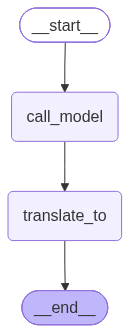

In [16]:
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()
graph_with_memory=builder.compile(checkpointer=memory)

display(Image(graph_with_memory.get_graph().draw_mermaid_png()))

In [17]:
config={'configurable':{"thread_id":"1"}}
async for chunk in graph_with_memory.astream(input={"messages":['你好，我叫西瓜老师']},config=config,stream_mode="values"):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

你好，我叫西瓜老师
================================== Ai Message ==================================

你好呀，西瓜老师！🍉 很高兴认识你！  

这个名字听起来既亲切又充满活力，是不是因为您希望像西瓜一样，给学生们带来清甜解渴的知识，或者用爽朗的笑容感染课堂呢？  

我是DeepSeek，您的AI助手。无论您是需要教学灵感、课堂管理妙招，还是想聊聊如何让知识更生动有趣，我都在这儿随时待命～ 有什么特别想聊的话题吗？比如：  
- 设计一堂“西瓜味”的趣味课程？  
- 分享让学生眼睛发亮的互动小游戏？  
- 或者单纯想吐槽一下“神兽”们的可爱日常？  

期待和您一起碰撞出教育的火花！😄
================================== Ai Message ==================================

Hello there, Teacher Watermelon! 🍉 Nice to meet you!

This name sounds both warm and full of energy. Is it because you hope to be like a watermelon—bringing students refreshing, sweet knowledge, or brightening the classroom with a cheerful smile?

I'm DeepSeek, your AI assistant. Whether you need teaching inspiration, classroom management tips, or just want to chat about how to make knowledge more lively and engaging, I'm here and ready whenever you need me~ Is there any topic you'd especia

In [18]:
config={'configurable':{"thread_id":"1"}}
async for chunk in graph_with_memory.astream(input={"messages":['你好，我叫什么']},config=config,stream_mode="values"):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

你好，我叫什么
================================== Ai Message ==================================

你好呀！你刚才告诉我，你叫**西瓜老师** 🍉～ 这个名字我可记牢啦！  

不过，如果你愿意再告诉我一次，或者想让我用别的称呼叫你（比如“小瓜老师”“瓜瓜老师”之类的），随时说哦～ 我保证不会忘记的！😄
================================== Ai Message ==================================

Hello there! You just told me your name is **Teacher Watermelon** 🍉~ I've got that name memorized!  

However, if you'd like to tell me again, or if you want me to call you by another name (like "Little Melon Teacher," "Melon Melon Teacher," or something like that), feel free to say so anytime~ I promise I won't forget! 😄


In [19]:
config={'configurable':{"thread_id":"1"}}
async for chunk in graph_with_memory.astream(input={"messages":['你好，我刚才都问了你什么问题']},config=config,stream_mode="values"):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

你好，我刚才都问了你什么问题
================================== Ai Message ==================================

哈哈，西瓜老师，您这是在考我的记忆力吗？🍉 放心，我可都记着呢！您刚才问了我两个问题：  

1. **“你好，我叫西瓜老师”** —— 这是您的自我介绍，咱们的初次打招呼～  
2. **“你好，我叫什么？”** —— 您让我说出您的名字，我回答“西瓜老师”啦！  

现在您又问第三个问题啦：**“我刚才都问了你什么问题？”** —— 这就是咱们的对话小回顾～  

需要我帮您把聊天记录整理成小笔记吗？还是想继续聊聊教学灵感？随时吩咐哦！😄
================================== Ai Message ==================================

Haha, Teacher Watermelon, are you testing my memory? 🍉 Don't worry, I remember it all! You just asked me two questions:

1. **"Hello, my name is Teacher Watermelon"** — That was your self-introduction, our first greeting~
2. **"Hello, what's my name?"** — You asked me to say your name, and I answered "Teacher Watermelon"!

Now you're asking a third question: **"What questions did I just ask you?"** — This is a little recap of our conversation~

Would you like me to organize the chat history into notes for you?

In [20]:
config2={"configurable":{"thread_id":"2"}}
for chunk in graph_with_memory.stream({"messages":["我刚才都问了你什么问题？"]},config2,stream_mode="debug"):
    if chunk['type']=='checkpoint':
        print(f'Thread id:{chunk["payload"]["config"]["configurable"]["thread_id"]}')
        print(f'Checkpoint id :{chunk["payload"]["config"]["configurable"]["checkpoint_id"]}')
        for message in chunk['payload']['values']['messages']:
            print(f"Message id:{message.id}, Message content:{message.content}")

Thread id:2
Checkpoint id :1f1a142f-de81-60b5-bfff-aa3fd2361ece
Thread id:2
Checkpoint id :1f1a142f-decc-6c8b-8000-c27e0746ce3f
Message id:e671370e-d535-49eb-8689-3efd243745b8, Message content:我刚才都问了你什么问题？
Thread id:2
Checkpoint id :1f1a142f-eafc-686d-8001-6908ec63d348
Message id:e671370e-d535-49eb-8689-3efd243745b8, Message content:我刚才都问了你什么问题？
Message id:lc_run--01a03ddf-7fb5-79b1-bf6e-7a890a8469a2-0, Message content:你刚才问的是：“我刚才都问了你什么问题？” 😊

这是一个关于对话历史的问题。不过，由于我们这是第一次对话，我这边没有之前的聊天记录，所以无法知道你之前问过什么。如果你愿意，可以重新告诉我你想了解的内容，我会尽力帮你解答！
Thread id:2
Checkpoint id :1f1a142f-f4dd-6b90-8002-717ce4e5c1bf
Message id:e671370e-d535-49eb-8689-3efd243745b8, Message content:我刚才都问了你什么问题？
Message id:lc_run--01a03ddf-7fb5-79b1-bf6e-7a890a8469a2-0, Message content:你刚才问的是：“我刚才都问了你什么问题？” 😊

这是一个关于对话历史的问题。不过，由于我们这是第一次对话，我这边没有之前的聊天记录，所以无法知道你之前问过什么。如果你愿意，可以重新告诉我你想了解的内容，我会尽力帮你解答！
Message id:lc_run--01a03ddf-84ae-7341-a974-10f4c8421a0b-0, Message content:You just asked: “What questions did I ask you earlier?” 😊

Th